In [2]:
from __future__ import annotations

# Core
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ML
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Viz
import plotly.express as px
import umap

# Local
from funcs.pgn_to_df_v2 import parser
import funcs.clustering_v2 as clst

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Global vars

In [3]:
RANDOM_SEED = 42069

#### Load

In [6]:
# Paths
DIR = Path.cwd().parents[1] / "data" / "daniel_data"
INPUT_PATH = DIR / "lichess_db_standard_rated_2017-09.pgn"
OUTPUT_PATH = DIR / "daniel_testdata_1m.csv"


#### Conversion

In [7]:

from funcs.pgn_to_df_workflow import convert_pgn_to_full_and_sample_csv

FULL_OUTPUT_PATH = DIR / "lichess_2014_09_raw_full.csv"
TRAIN_OUTPUT_PATH = DIR / "lichess_2014_09_raw_300k.csv"

info = convert_pgn_to_full_and_sample_csv(
    INPUT_PATH,
    FULL_OUTPUT_PATH,
    TRAIN_OUTPUT_PATH,
    sample_size=300_000,
    random_state=42,
    chunk_size=100_000,

    # Compact full dataset.
    full_include_moves_san=True,
    full_include_annotation_series=True,
    full_include_moves_pgn=False,

    # Richer 300K training sample.
    sample_include_moves_san=True,
    sample_include_annotation_series=True,
    sample_include_moves_pgn=True,
)

print(info)

KeyboardInterrupt: 

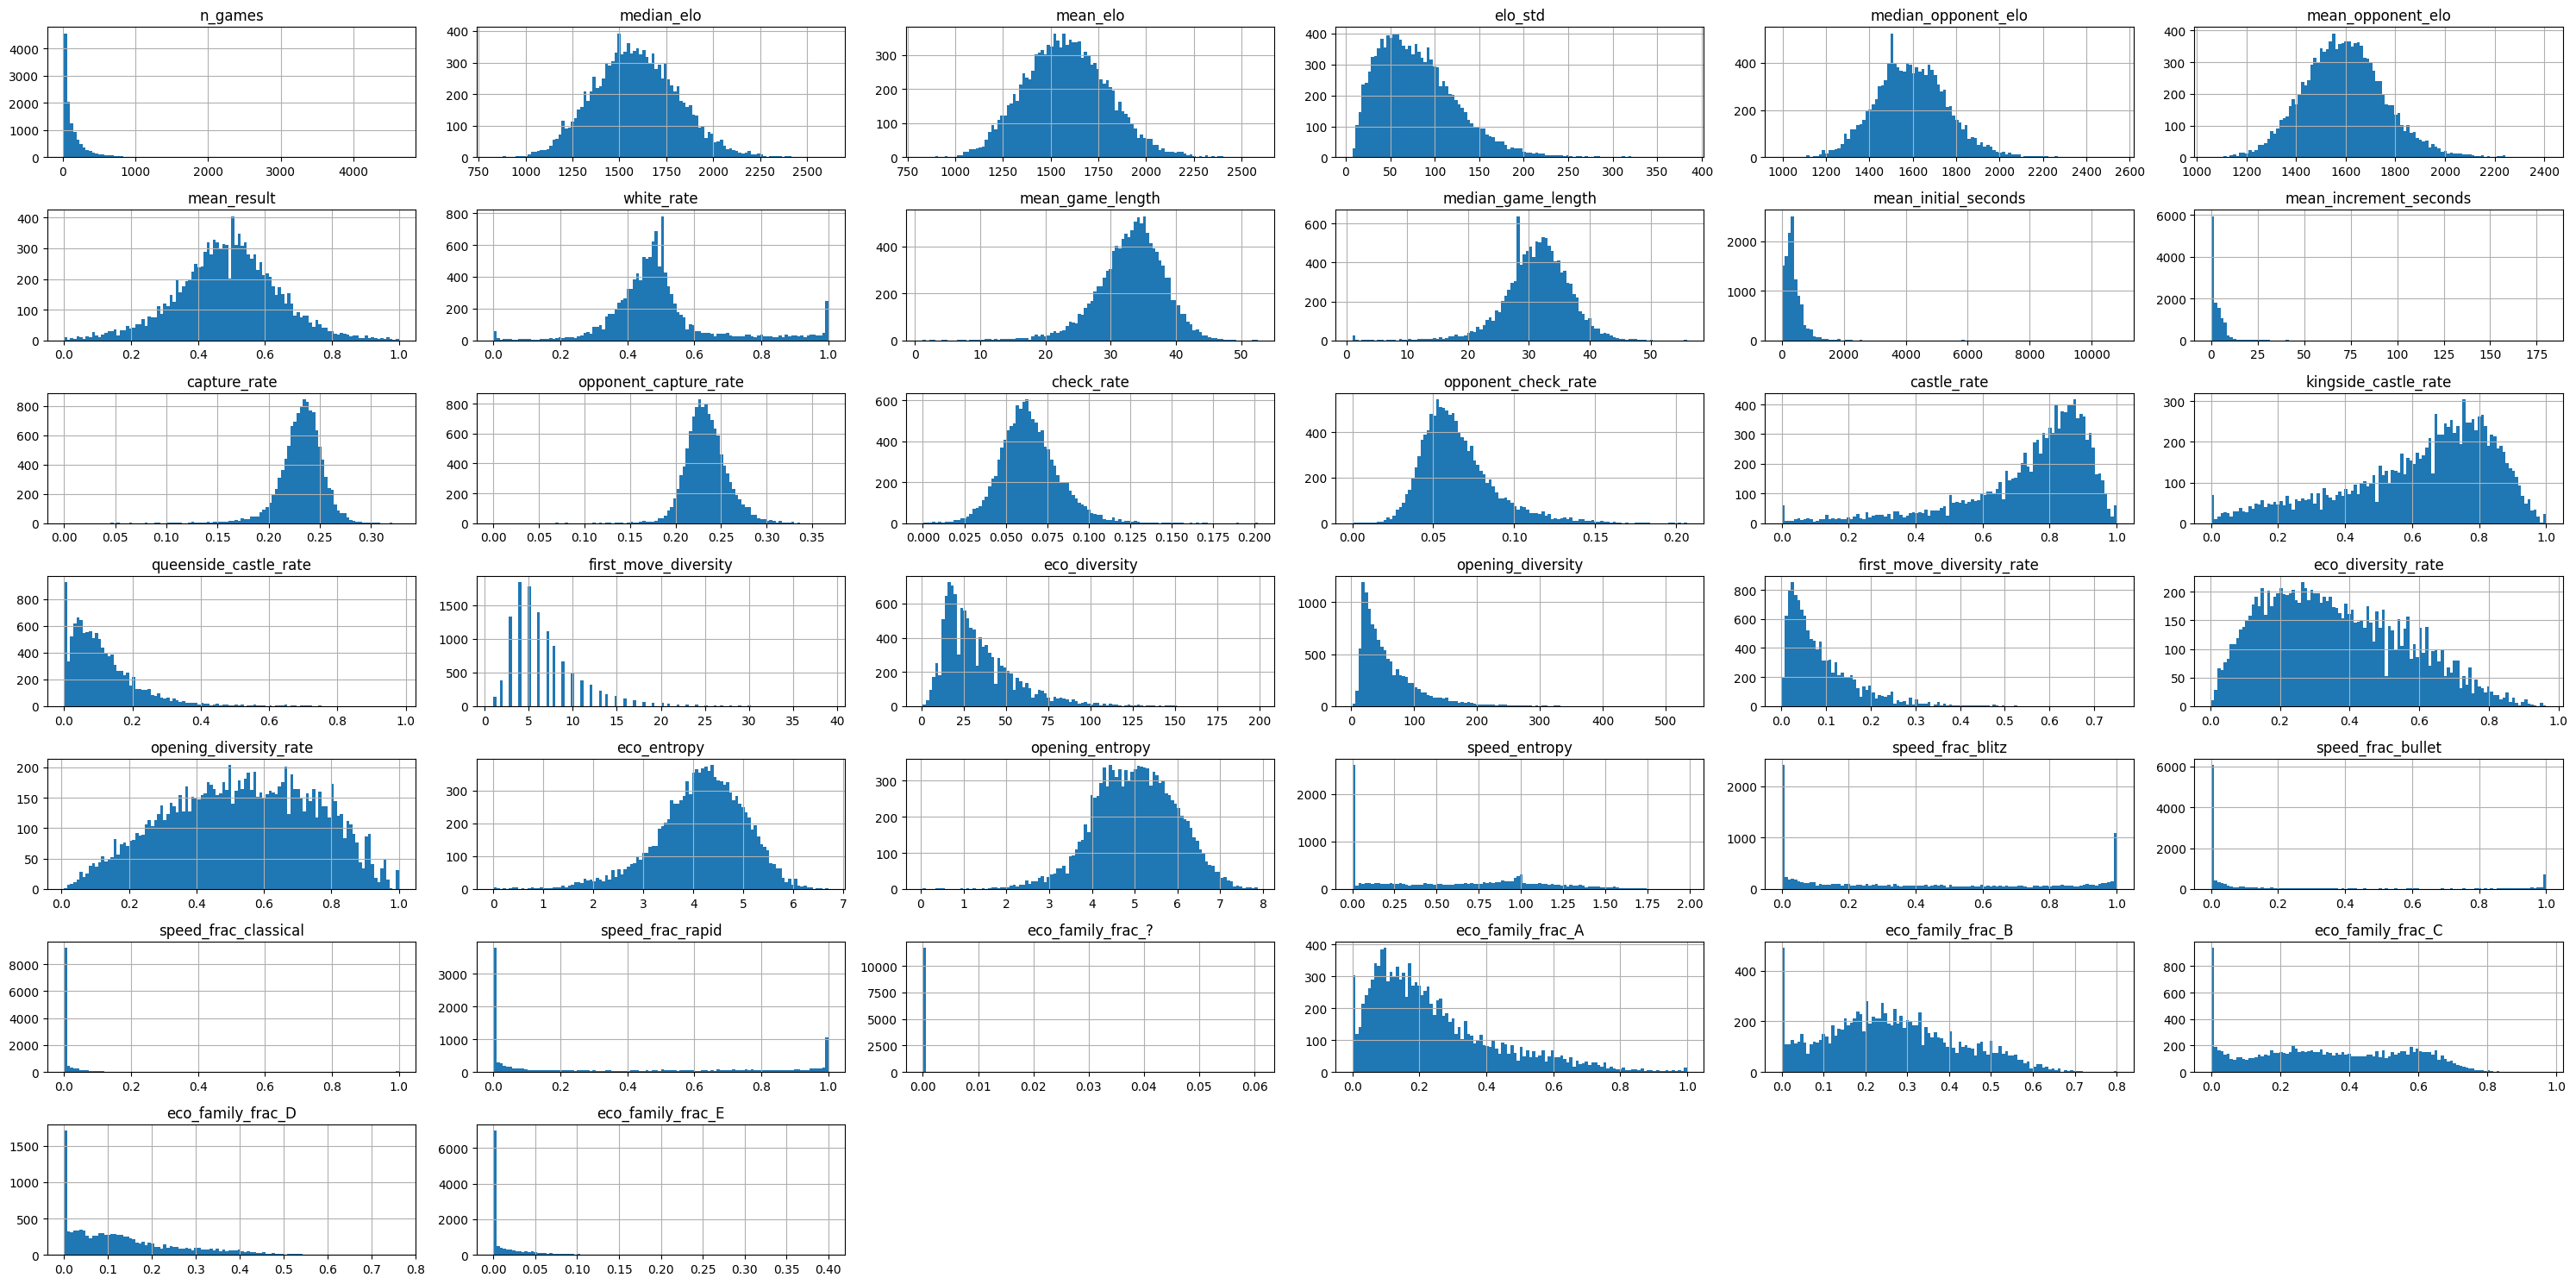

In [8]:
bins = np.sqrt(len(X)).astype(int)

# Plot all numeric features in X with larger figure
X.hist(bins=bins, figsize=(30, 15))
plt.tight_layout()
plt.show()

#### Removing ELO informaton + StandardScaler

In [9]:
feature_names = X.columns

# Dropping columns with "elo" in their name
cols_dropped = [col for col in feature_names if "elo" in col]
cols_kept = X.drop(columns=cols_dropped).columns

# StandardScaler
X_scaled = StandardScaler().fit_transform(X.drop(columns=cols_dropped))
X_scaled = pd.DataFrame(X_scaled, columns=cols_kept, index=X.index)

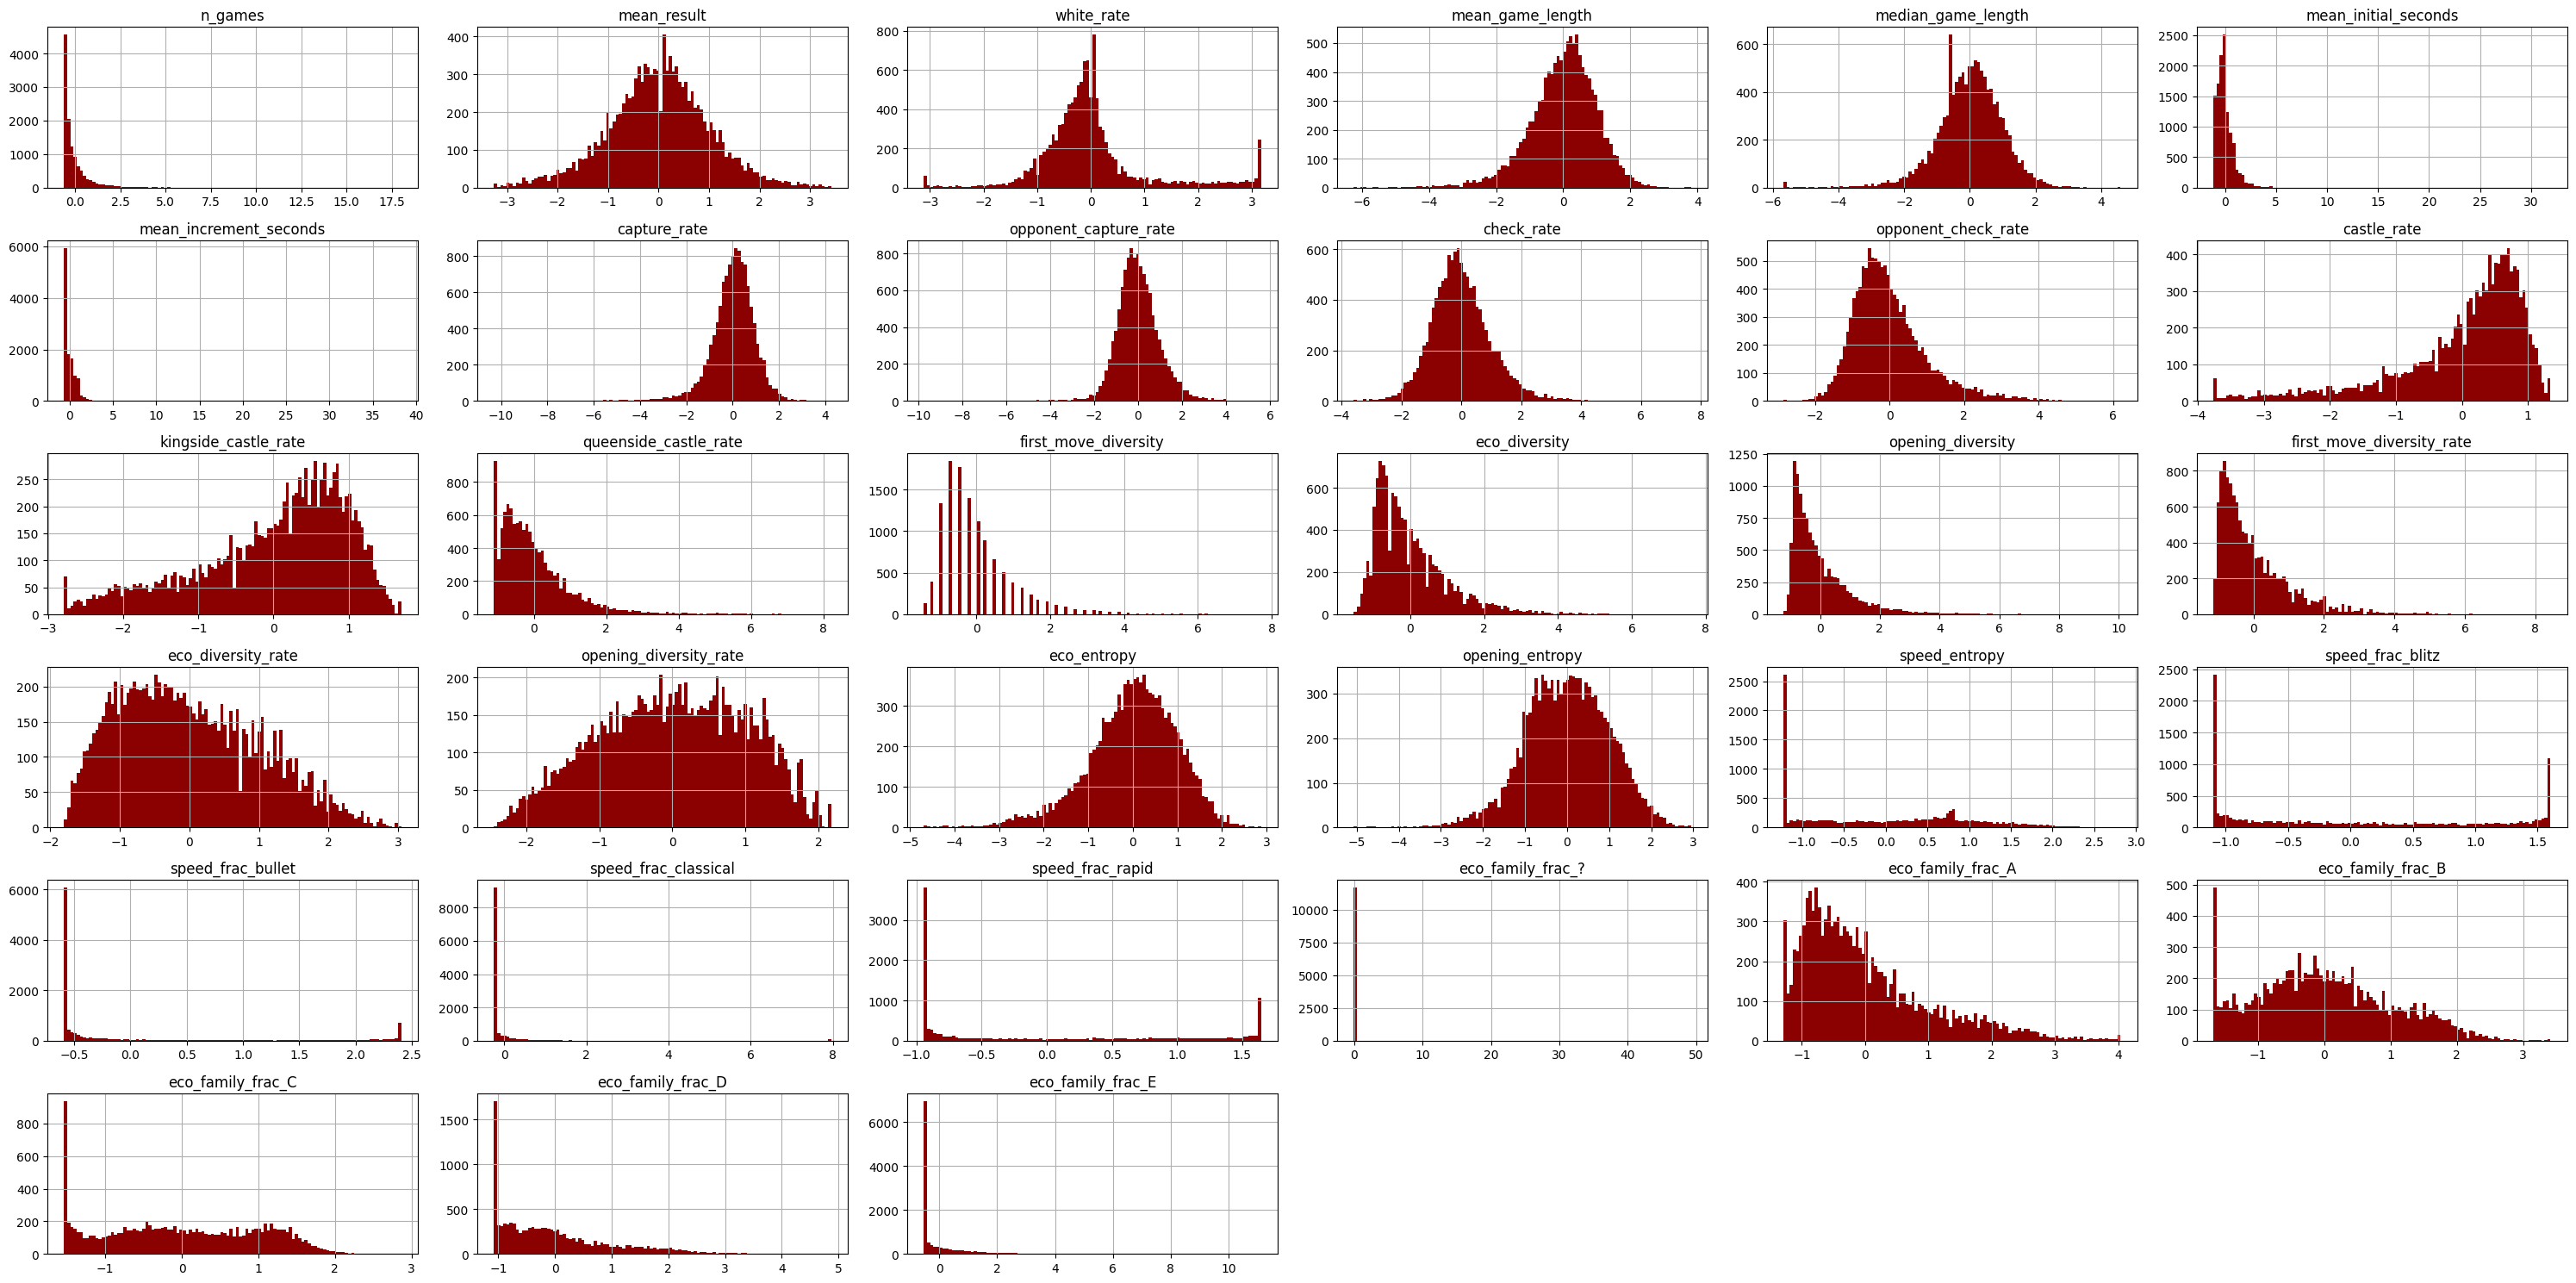

In [10]:
# Plot, again
X_scaled.hist(bins=bins, figsize=(30, 15), color='darkred')
plt.tight_layout()
plt.show()

In [ ]:
# Representation used for clustering.
# Start with the original scaled features as a baseline.
X_cluster = X_scaled.copy()
representation_name = "scaled_features"

labels = kmeans.fit_predict(X_cluster)

embedding_km = umap.UMAP(
    n_components=3,
    random_state=RANDOM_SEED,
).fit_transform(X_cluster)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=RANDOM_SEED)
X_pca_array = pca.fit_transform(X_scaled)

X_pca = pd.DataFrame(
    X_pca_array,
    columns=[f"pc_{i+1}" for i in range(X_pca_array.shape[1])],
    index=X_scaled.index,
)

print(f"Original dimensions: {X_scaled.shape[1]}")
print(f"PCA dimensions: {X_pca.shape[1]}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

In [ ]:
X_cluster = X_pca.copy()
representation_name = "pca_95pct_variance"

In [ ]:
k_values = range(2, 21)
rows = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_SEED,
        n_init=20,
    )

    labels = kmeans.fit_predict(X_cluster)

    rows.append({
        "representation": representation_name,
        "k": k,
        "sse": kmeans.inertia_,
        "silhouette": silhouette_score(X_cluster, labels),
        "calinski_harabasz": calinski_harabasz_score(X_cluster, labels),
        "davies_bouldin": davies_bouldin_score(X_cluster, labels),
    })

cluster_scores = pd.DataFrame(rows)
cluster_scores

In [ ]:
eps_container = np.round(np.arange(0.25, 5.25, 0.25), 2)
n_clusters_container = []
n_noise_container = []

for eps in eps_container:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_cluster)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = sum(labels == -1)

    n_clusters_container.append(n_clusters)
    n_noise_container.append(n_noise)

In [ ]:
umap_model = umap.UMAP(
    n_components=10,
    n_neighbors=30,
    min_dist=0.0,
    metric="euclidean",
    random_state=RANDOM_SEED,
)

X_umap_latent_array = umap_model.fit_transform(X_scaled)

X_umap_latent = pd.DataFrame(
    X_umap_latent_array,
    columns=[f"umap_latent_{i+1}" for i in range(X_umap_latent_array.shape[1])],
    index=X_scaled.index,
)

X_cluster = X_umap_latent.copy()
representation_name = "umap_10d"

#### Initial 3D UMAP

In [11]:
feature_names_in_scaled = X_scaled.columns
color_by = feature_names_in_scaled[5]

In [ ]:
color_by = "mean_elo"

embedding = umap.UMAP(
    n_components=3,
    random_state=RANDOM_SEED,
).fit_transform(X_scaled)

embedding_df = pd.DataFrame(
    embedding,
    columns=["umap_1", "umap_2", "umap_3"],
    index=X_scaled.index,
)

embedding_df["row_index"] = X_scaled.index

# Add metadata from the original X, not from X_scaled
embedding_df["mean_elo"] = X.loc[embedding_df["row_index"], "mean_elo"].values
embedding_df["n_games"] = X.loc[X_scaled.index, "n_games"].values

c:\Users\foghd\miniconda3\envs\appml_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
fig = px.scatter_3d(
    embedding_df,
    x="umap_1",
    y="umap_2",
    z="umap_3",
    color=color_by,
    hover_data=["row_index"],
    opacity=0.8,
    title=f"3D UMAP colored by {color_by}",
    width=1050,
    height=780,
)

fig.show()

#### DBSCAN & UMAP

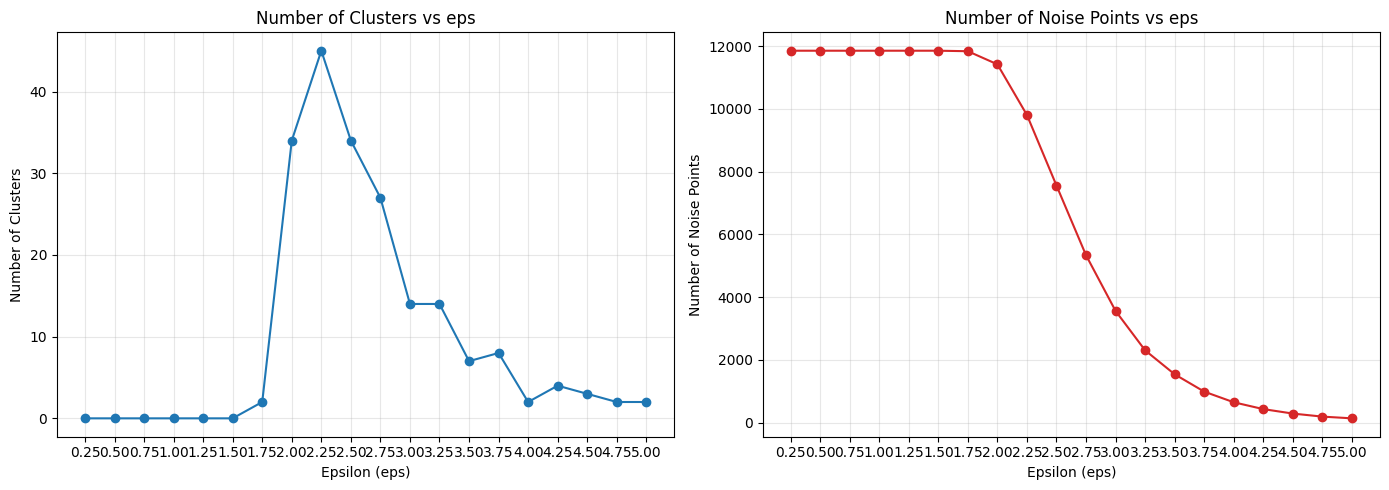

In [16]:
eps_container = np.round(np.arange(0.25, 5.25, 0.25), 2)
n_clusters_container = []
n_noise_container = []

for eps in eps_container:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = sum(labels == -1)

    n_clusters_container.append(n_clusters)
    n_noise_container.append(n_noise)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

axes[0].plot(eps_container, n_clusters_container, marker="o", color="tab:blue")
axes[0].set_title("Number of Clusters vs eps")
axes[0].set_xlabel("Epsilon (eps)")
axes[0].set_ylabel("Number of Clusters")
axes[0].set_xticks(eps_container)
axes[0].grid(True, alpha=0.3)

axes[1].plot(eps_container, n_noise_container, marker="o", color="tab:red")
axes[1].set_title("Number of Noise Points vs eps")
axes[1].set_xlabel("Epsilon (eps)")
axes[1].set_ylabel("Number of Noise Points")
axes[1].set_xticks(eps_container)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# New DBSCAN with eps=3.5 (chosen based on the above plots)
dbscan = DBSCAN(eps=3.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Umap of DBSCAN results
embedding_db = umap.UMAP(n_components=3, random_state=44).fit_transform(X_scaled)
embedding_db_df = pd.DataFrame(embedding_db, columns=["umap_1", "umap_2", "umap_3"])
embedding_db_df["row_index"] = X_scaled.index
embedding_db_df["cluster"] = labels

embedding_db_df["cluster"] = embedding_db_df["cluster"].astype(str) # To convert to string for better coloring in plotly

fig_db = px.scatter_3d(
    embedding_db_df,
    x="umap_1",
    y="umap_2",
    z="umap_3",
    color="cluster",
    hover_data=["row_index"],
    opacity=0.8,
    title=f"3D UMAP colored by DBSCAN Clusters",
    width=1050,
    height=780,
)

fig_db.show()

c:\Users\foghd\miniconda3\envs\appml_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### K-means

That is not unusual. SSE/inertia is always monotonically decreasing with k, because more centroids can always fit the data at least as well. The elbow method only helps when there is a visible “diminishing returns” point. If there is no clear elbow, it usually means one of these:

Your data does not have a strong natural cluster structure.
KMeans is not a good model for the geometry of your data.
The features describe a smooth continuum of player styles rather than discrete archetypes.
The feature space is noisy, high-dimensional, or dominated by weakly informative variables.

In your case, since this is player-style data, I would not assume that there is a “correct” number of clusters. Chess players may lie on gradients: aggressive/passive, opening-specialist/generalist, fast/slow games, tactical/positional, etc. That does not necessarily form clean blobs.

Conclusion: chess players are not clusterable - they're humans, and humans lie on a continuum

In [18]:
k_values = range(2, 21)
rows = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=RANDOM_SEED,
        n_init=20,
    )

    labels = kmeans.fit_predict(X_scaled)

    rows.append({
        "k": k,
        "sse": kmeans.inertia_,
        "silhouette": silhouette_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
    })

cluster_scores = pd.DataFrame(rows)
cluster_scores

,k,sse,silhouette,calinski_harabasz,davies_bouldin
0,2,348984.797000,0.099428,1434.318734,2.586278
1,3,323849.914394,0.093909,1232.699694,2.619561
2,4,305940.209540,0.094300,1101.077968,2.501444
3,5,292008.559176,0.095246,1006.474653,2.326778
4,6,279839.219037,0.098208,943.180164,2.146486
5,7,270679.584178,0.084930,879.332929,2.132568
6,8,263102.834158,0.086011,824.091436,1.947996
7,9,256740.134867,0.092386,775.584757,2.037459
8,10,251085.279224,0.087820,734.516628,2.055054
9,11,243513.096067,0.088460,718.393634,1.917380


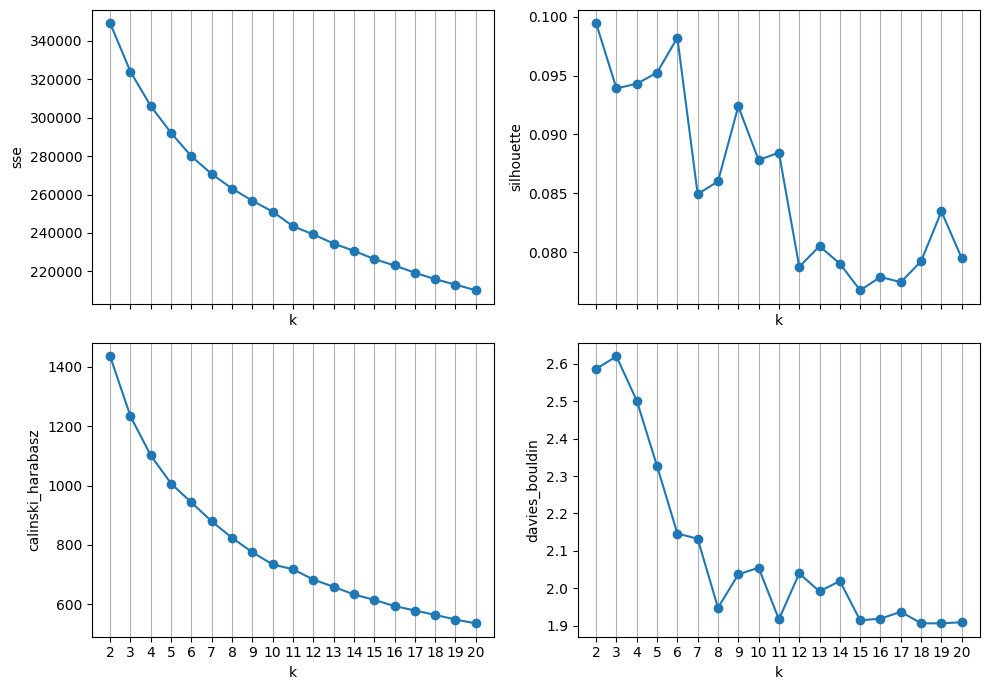

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

metrics = ["sse", "silhouette", "calinski_harabasz", "davies_bouldin"]

for ax, col in zip(axes.ravel(), metrics):
    ax.plot(cluster_scores["k"], cluster_scores[col], marker="o")
    ax.set_xticks(cluster_scores["k"])
    ax.set_xlabel("k")
    ax.set_ylabel(col)
    ax.grid(axis="x", which="major")

plt.tight_layout()
plt.show()


In [20]:
kmeans = KMeans(
        n_clusters=7,
        random_state=RANDOM_SEED,
        n_init=25,
    )
labels = kmeans.fit_predict(X_scaled)


# Umap of KMeans results
embedding_km = umap.UMAP(n_components=3, random_state=RANDOM_SEED).fit_transform(X_scaled)
embedding_km_df = pd.DataFrame(embedding_km, columns=["umap_1", "umap_2", "umap_3"])
embedding_km_df["row_index"] = X_scaled.index
embedding_km_df["cluster"] = labels


embedding_km_df["cluster"] = embedding_km_df["cluster"].astype(str) # To convert to string for better coloring in plotly


fig_km = px.scatter_3d(
    embedding_km_df,
    x="umap_1",
    y="umap_2",
    z="umap_3",
    color="cluster",
    hover_data=["row_index"],
    opacity=0.8,
    title=f"3D UMAP colored by KMeans Clusters",
    width=1050,
    height=780,
)

fig_km.show()

c:\Users\foghd\miniconda3\envs\appml_env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


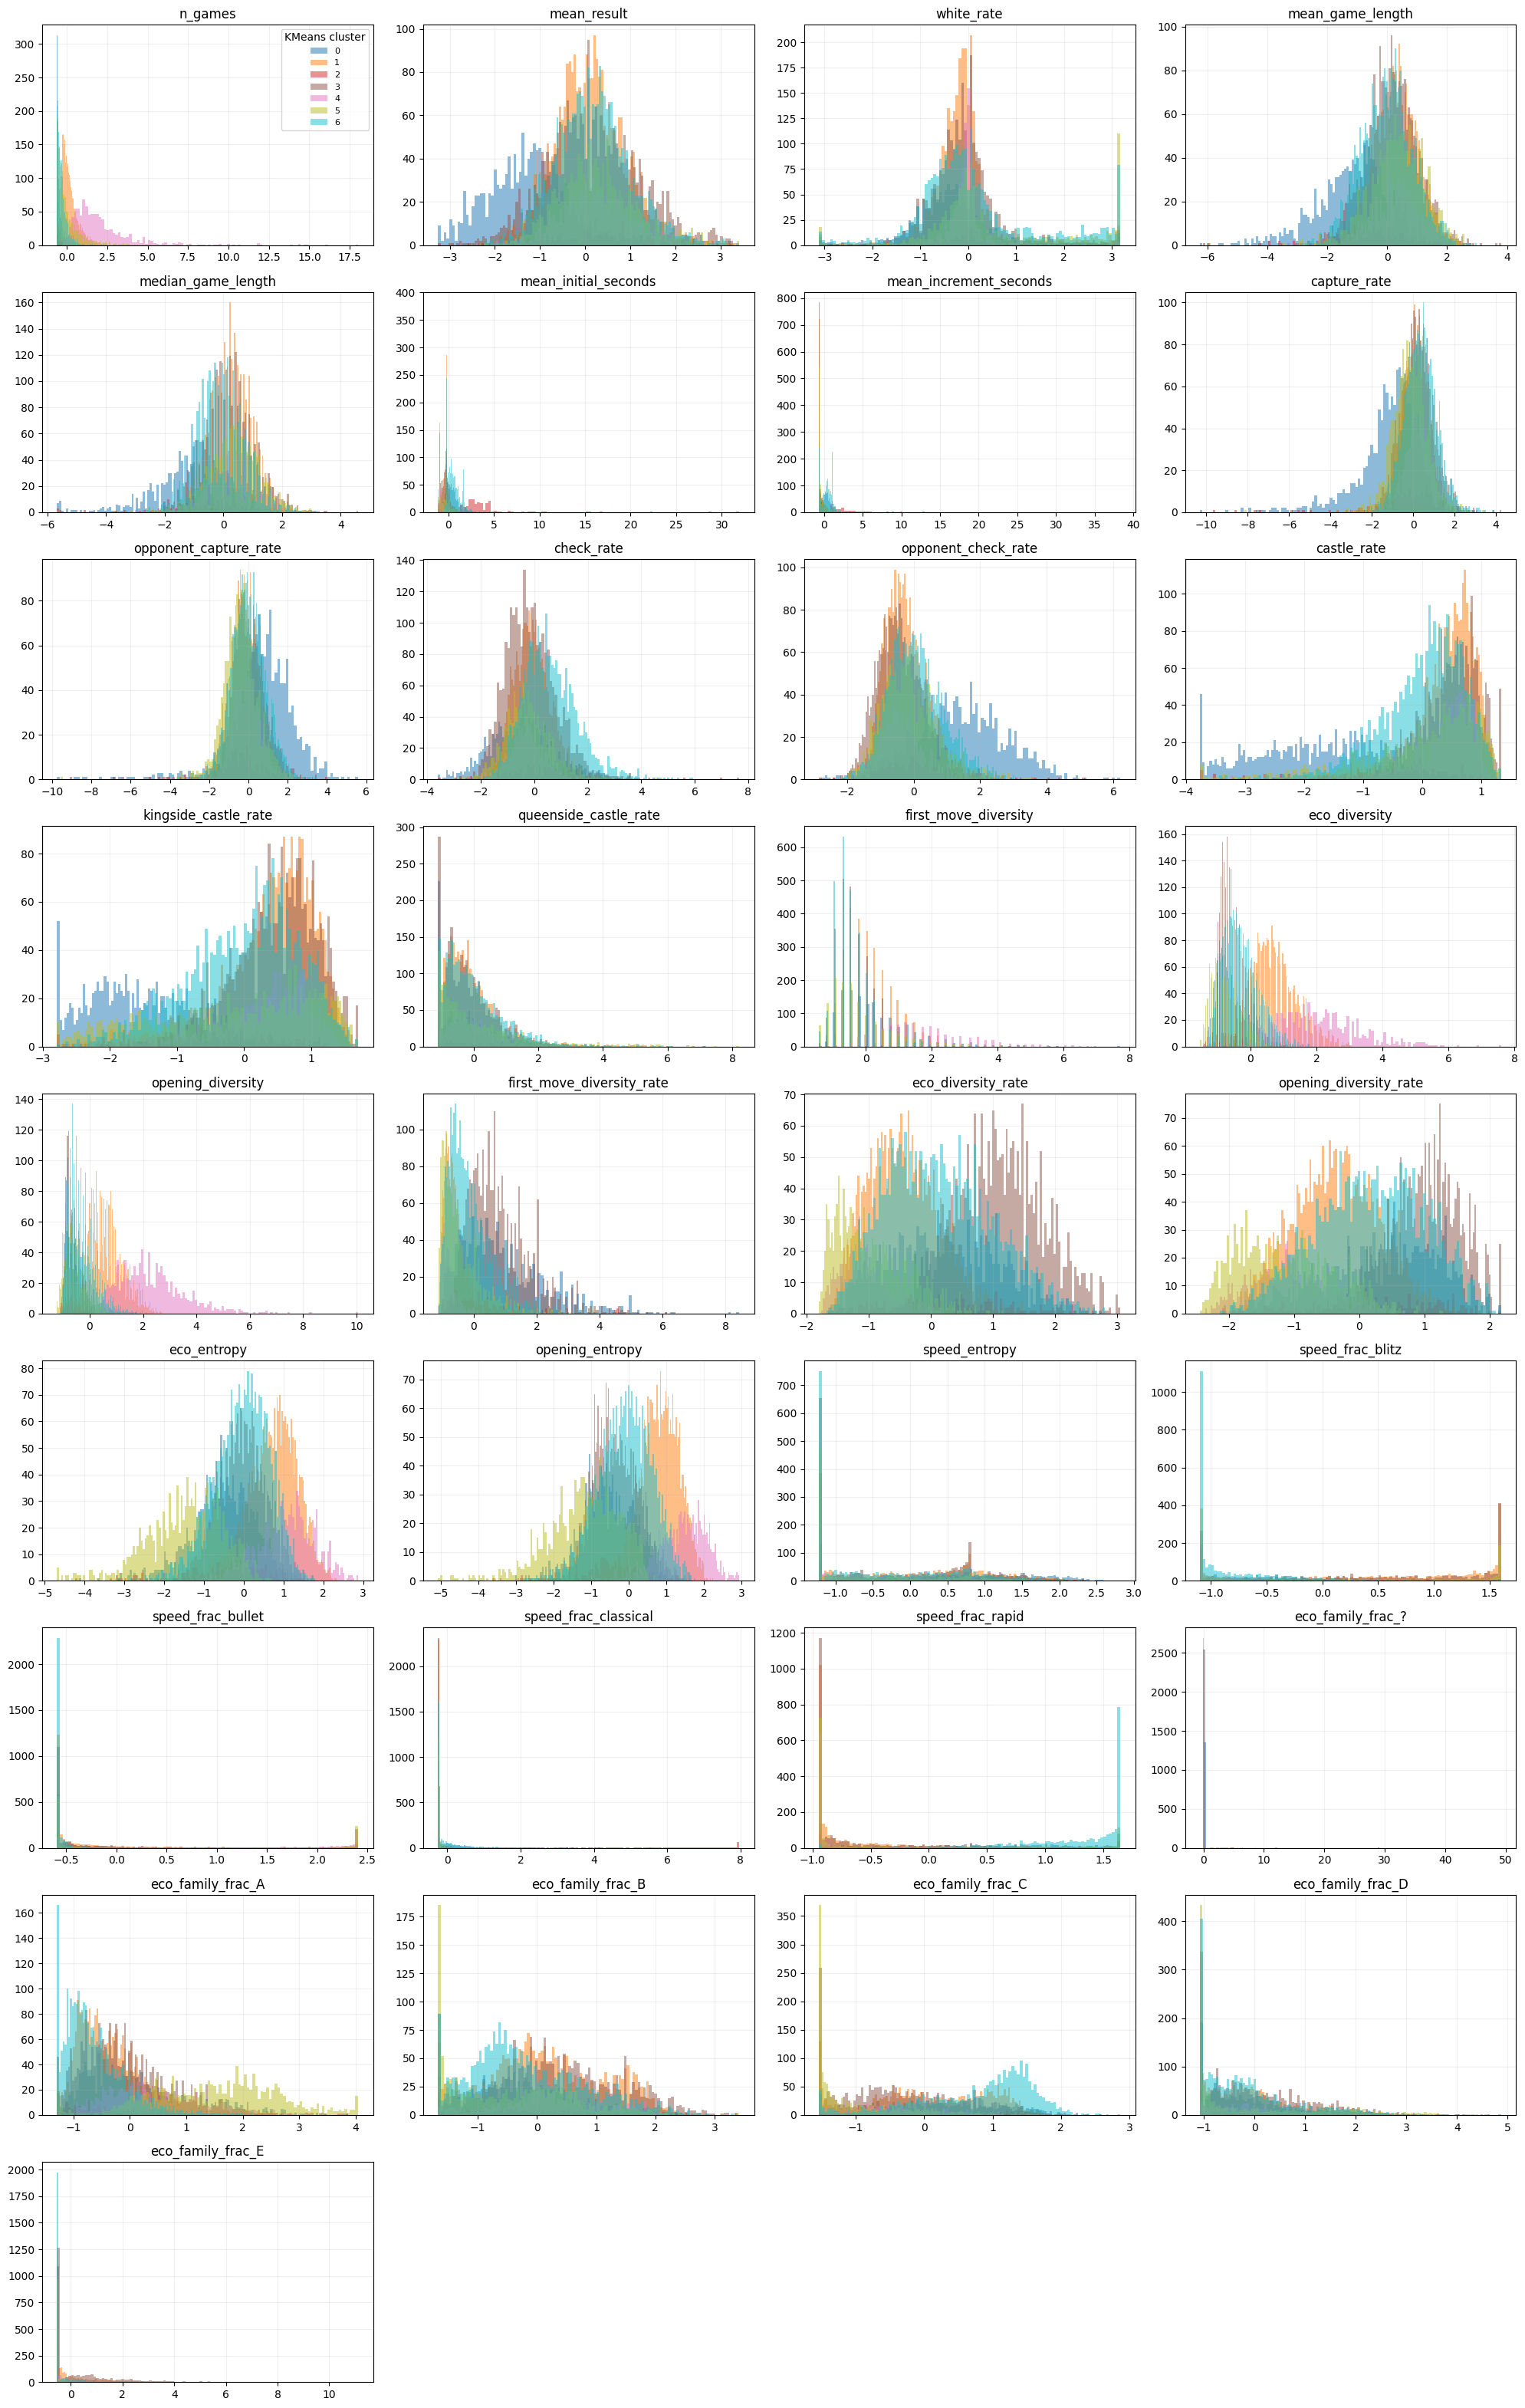

In [21]:
# Add KMeans cluster labels to the scaled data
X_scaled_clustered = X_scaled.copy()
X_scaled_clustered["cluster"] = labels.astype(str)

cluster_ids = sorted(X_scaled_clustered["cluster"].unique(), key=int)
cmap = plt.get_cmap("tab10", len(cluster_ids))
colors = [cmap(i) for i in range(len(cluster_ids))]

features = X_scaled.columns
n_features = len(features)
ncols = 4
nrows = int(np.ceil(n_features / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).ravel()

for ax, feature in zip(axes, features):
    for i, cluster in enumerate(cluster_ids):
        vals = X_scaled_clustered.loc[X_scaled_clustered["cluster"] == cluster, feature]
        ax.hist(vals, bins=bins, alpha=0.5, color=colors[i], label=cluster)
    ax.set_title(feature)
    ax.grid(True, alpha=0.2)

for ax in axes[n_features:]:
    ax.axis("off")

axes[0].legend(title="KMeans cluster", fontsize=8)
plt.tight_layout()
plt.show()